## 1. Setup, Dependências e Gestão de Diretórios

Esta etapa inicial garante a integridade do ambiente de execução, realizando a importação das bibliotecas especializadas e a configuração da estrutura de arquivos necessária para a persistência dos resultados.

### Bibliotecas Core
* **`NetworkX`**: Motor principal para modelagem, manipulação e cálculo de métricas em estruturas de grafos complexos.
* **`Pyvis`**: Biblioteca de visualização dinâmica para renderização de grafos em ambiente web (HTML/JavaScript).
* **`Matplotlib` & `Scipy`**: Suporte para plotagem estática e operações de álgebra linear em matrizes esparsas.
* **`Pandas` & `Json`**: Manipulação e exportação de dados estruturados e matrizes de adjacência.

### Persistência e Integridade do Sistema
Implementamos uma rotina de **verificação automática de diretórios**. O script valida a existência das pastas abaixo e as cria caso necessário, prevenindo erros de E/S (*I/O Errors*) durante o salvamento dos artefatos:
* `../data/imagens/` (Gráficos Estáticos)
* `../data/matriz_adj/` (Dados Algébricos)
* `../data/visualizacoes_interativas/` (Modelos Web)

> **Importante:** Certifique-se de que os arquivos `ner_camaroes.json` e `ner_cocobambu.json` estejam presentes no diretório `../data/processados/` para o funcionamento do pipeline.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import json
import os
import scipy
from pyvis.network import Network

# Configurações de diretórios
DIRS = ["../data/imagens", "../data/matriz_adj", "../data/visualizacoes_interativas"]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

# Carregamento dos dados processados
with open("../data/processados/ner_camaroes.json", "r", encoding="utf-8") as f:
    raw_cam = json.load(f)
with open("../data/processados/ner_cocobambu.json", "r", encoding="utf-8") as f:
    raw_cb = json.load(f)

## 2. Extração de Entidades e Cálculo de Vizinhança

Nesta etapa, consolidamos o pipeline de processamento que transforma os dados brutos em conjuntos de dados prontos para a modelagem de rede. O foco aqui é a **interoperabilidade** entre as diferentes fontes de dados.

### Mapeamento de Macro-Categorias
* **Unificação de Chaves**: A função `extrair_por_macro_categoria` atua como um *wrapper* que traduz as nomenclaturas específicas do JSON (ex: `entradas_e_petiscos`) em categorias legíveis para a análise (ex: `Entradas`).
* **Consolidação Bipartida**: Garante que cada prato extraído contenha sua lista atômica de ingredientes, permitindo que cada par (Prato, Ingrediente) se torne uma aresta no grafo.

### Métrica de Proximidade (Coeficiente de Jaccard)
Implementamos a função de similaridade baseada na **Teoria dos Conjuntos**. Para o contexto de grafos, o Índice de Jaccard mede a sobreposição das vizinhanças ($N$) de dois nós de pratos:
$$J(u, v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}$$
* **Interseção ($N(u) \cap N(v)$)**: Representa o conjunto de ingredientes idênticos compartilhados entre os pratos.
* **União ($N(u) \cup N(v)$)**: Representa o repertório total de ingredientes distintos envolvidos em ambos.

> **Objetivo**: Quantificar matematicamente a "assinatura técnica" de cada restaurante, provando se pratos com nomes diferentes são, na verdade, variações de uma mesma base de ingredientes.

In [4]:

def extrair_por_macro_categoria(json_data, macro):
    cardapio = json_data.get("cardapio_completo", {})
    # Mapeamento robusto para as chaves do seu JSON
    mapeamento = {
        'Entradas': ['entradas_e_petiscos'],
        'Pratos Principais': ['pratos_principais'],
        'Saladas': ['saladas'],
        'Sobremesas': ['sobremesas']
    }
    lista_final = []
    chaves = mapeamento.get(macro, [])
    for c in chaves:
        lista_final.extend(cardapio.get(c, []))
    return lista_final

def calcular_jaccard(g, u, v):
    """Métrica central para a sua explanação em ED2"""
    if u not in g or v not in g: return 0
    viz_u, viz_v = set(g.neighbors(u)), set(g.neighbors(v))
    inter = len(viz_u.intersection(viz_v))
    uniao = len(viz_u.union(viz_v))
    return inter / uniao if uniao > 0 else 0

# Carregamento dos dados
with open("../data/processados/ner_camaroes.json", "r", encoding="utf-8") as f: raw_cam = json.load(f)
with open("../data/processados/ner_cocobambu.json", "r", encoding="utf-8") as f: raw_cb = json.load(f)

## 3. Lógica de Grafo Bipartido e Estilização de Conectividade

Esta célula contém a função principal do projeto, responsável por converter as listas de ingredientes em uma rede complexa. A modelagem utiliza o conceito de **Grafo Bipartido**, onde as conexões ocorrem exclusivamente entre o conjunto de Pratos e o conjunto de Ingredientes.

### 🛠️ Destaques da Implementação
* **Filtragem de Ruído (Subgrafo Induzido)**: Implementamos uma poda automática para manter apenas ingredientes com grau $d(v) > 1$ (compartilhados entre pratos) ou nós que representam pratos. Isso foca a análise na **Vizinhança Comum** e reduz o ruído visual de ingredientes exclusivos.
* **Codificação Visual de Canais (Hubs)**: Para evidenciar a "espinha dorsal" que une o Camarões ao Coco Bambu, aplicamos uma dupla codificação nas arestas de ingredientes com conectividade $d(v) > 2$:
    * **Magnitude**: Aumento da espessura da aresta para destacar o peso do ingrediente na rede.
    * **Contraste Cromático**: Transição de *Silver* (conexões comuns) para *Dark Gray* (conexões de hubs), aumentando a legibilidade tanto no Matplotlib quanto no Pyvis.
* **Análise de Similaridade (Jaccard)**: O pipeline quantifica a proximidade técnica entre pratos homônimos através da razão entre a interseção e a união das suas vizinhanças: $J(u, v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}$.



### 📂 Saídas do Pipeline
1.  **Relatório de Pares Espelhados**: Identificação automatizada das maiores convergências técnicas impressas no console.
2.  **Exportação PNG**: Snapshot estático de alta resolução (300 DPI) para documentação acadêmica.
3.  **Exportação HTML (Pyvis)**: Renderização dinâmica com motor de física ativa, sincronizando as propriedades de peso e cor definidas no NetworkX para a web.


In [9]:
def plotar_analise_final(macro_nome):
    lista_cam = extrair_por_macro_categoria(raw_cam, macro_nome)
    lista_cb = extrair_por_macro_categoria(raw_cb, macro_nome)
    
    G = nx.Graph()
    # Povoamento Bipartido
    for rest, lista, cor in [("Camarões", lista_cam, "skyblue"), ("Coco Bambu", lista_cb, "orange")]:
        for item in lista:
            id_p = f"({rest}) {item['nome']}"
            G.add_node(id_p, type='PRATO', restaurant=rest, color=cor, label=item['nome'])
            for ing in item.get('ingredientes', []):
                ing_node = ing.lower().strip()
                G.add_node(ing_node, type='ING', color='lightgray')
                G.add_edge(id_p, ing_node)

    # Filtragem de nós isolados
    S = G.subgraph([n for n, d in G.degree() if d > 1 or G.nodes[n].get('type')=='PRATO']).copy()
    
    # --- NOVO BLOCO DE ESTILIZAÇÃO DE ARESTAS ---
    edge_widths = []
    edge_colors = []
    for u, v in S.edges():
        # Critério: Se um dos nós for ingrediente e estiver em mais de 2 pratos
        # Se quiser destacar MAIS ingredientes, mude o > 2 para > 1
        is_hub = (S.nodes[u].get('type') == 'ING' and S.degree(u) > 2) or \
                 (S.nodes[v].get('type') == 'ING' and S.degree(v) > 2)
        
        if is_hub:
            edge_widths.append(3.0)      # Aresta bem grossa
            edge_colors.append('#555555') # Cinza escuro para contraste
        else:
            edge_widths.append(0.5)      # Aresta fina
            edge_colors.append('silver')  # Cor clara (recua visualmente)
    # --------------------------------------------

    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(S, k=0.5, iterations=50)
    
    nx.draw(S, pos, labels={n: S.nodes[n].get('label', n) for n in S.nodes()},
            with_labels=True, 
            node_color=[S.nodes[n].get('color', 'lightgray') for n in S.nodes()],
            node_size=[1300 if S.nodes[n].get('type')=='PRATO' else 300 for n in S.nodes()],
            font_size=8, 
            width=edge_widths,   # Usa a nossa lista de espessuras
            edge_color=edge_colors, # Usa a nossa lista de cores
            alpha=0.8)

    plt.title(f"Similaridade Gastronômica: {macro_nome}", fontsize=16)
    cam_patch = mpatches.Patch(color='skyblue', label='Camarões (Natal)')
    cb_patch = mpatches.Patch(color='orange', label='Coco Bambu (Fortaleza)')
    plt.legend(handles=[cam_patch, cb_patch], loc='upper right')
    
    file_name = f"similaridade_{macro_nome.lower().replace(' ', '_')}.png"
    plt.savefig(f"../data/imagens/{file_name}", dpi=300, bbox_inches="tight")
    plt.show()

    # --- ATUALIZAÇÃO PYVIS PARA DESTAQUE ---
    net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white')
    
    # Importante: repassar os atributos de estilo para o objeto do Pyvis
    for i, (u, v) in enumerate(S.edges()):
        S.edges[u, v]['width'] = edge_widths[i]
        S.edges[u, v]['color'] = edge_colors[i]
        
    net.from_nx(S)
    net.save_graph(f"../data/visualizacoes_interativas/similaridade_{macro_nome.lower().replace(' ', '_')}.html")
    # ---------------------------------------

    # Relatório de Jaccard (Agora após o plot para não travar o return)
    pc = [n for n, d in S.nodes(data=True) if d.get('restaurant')=='Camarões']
    pb = [n for n, d in S.nodes(data=True) if d.get('restaurant')=='Coco Bambu']
    print(f"\n Top Similares em {macro_nome}:")
    matches = sorted([(p1, p2, calcular_jaccard(S, p1, p2)) for p1 in pc for p2 in pb], key=lambda x: x[2], reverse=True)
    for p1, p2, s in matches[:5]:
        if s > 0.1: print(f" {s:.1%} | {p1} <-> {p2}")

    return S

## 4. Processamento Modular e Exportação de Matrizes (Representação Algébrica)

Nesta etapa, o pipeline é executado para cada **Macro-Categoria**, permitindo a análise isolada da topologia de cada rede e a geração das matrizes de adjacência.

### Estratégia de Execução
* **Isolamento de Contexto**: O processamento individual das variáveis ($E, S, P, SB$) evita a poluição visual do grafo global e permite comparar métricas de centralidade entre diferentes setores do cardápio.
* **Persistência de Estado**: Manter os objetos `NetworkX` em variáveis globais facilita a auditoria dos dados e a exportação subsequente sem a necessidade de reprocessamento.

### Representação Matemática
A **Matriz de Adjacência** é a conversão da estrutura topológica em uma forma algébrica $A$, onde para um grafo com $n$ nós:
* $A_{ij} = 1$: Se existe uma aresta entre o nó $i$ e o nó $j$ (relação prato-ingrediente).
* $A_{ij} = 0$: Caso não haja conexão.



### Output de Dados
Os subgrafos são exportados em dois formatos:
1.  **CSV**: Matrizes de adjacência para análise quantitativa e conferência de vizinhança técnica.
2.  **HTML (Pyvis)**: Visualizações interativas para exploração dinâmica da rede.


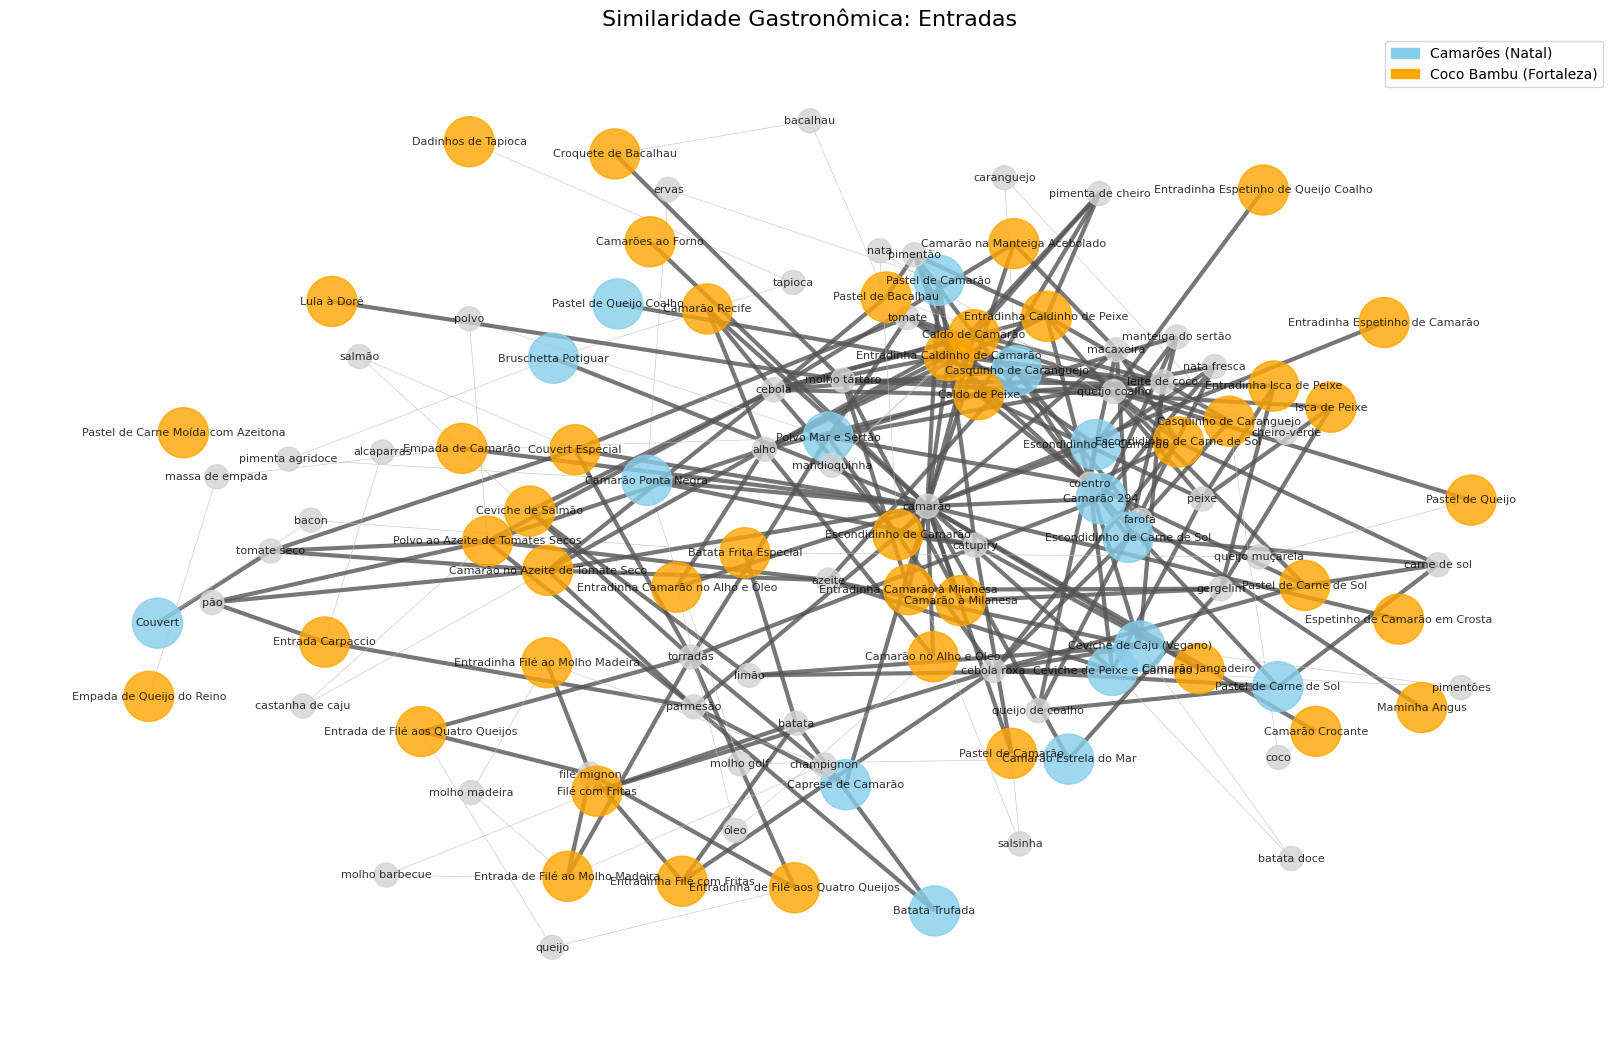


 Top Similares em Entradas:
 100.0% | (Camarões) Pastel de Queijo Coalho <-> (Coco Bambu) Entradinha Espetinho de Queijo Coalho
 66.7% | (Camarões) Pastel de Camarão <-> (Coco Bambu) Camarão Jangadeiro
 60.0% | (Camarões) Pastel de Carne de Sol <-> (Coco Bambu) Pastel de Carne de Sol
 50.0% | (Camarões) Pastel de Camarão <-> (Coco Bambu) Pastel de Camarão
 50.0% | (Camarões) Pastel de Queijo Coalho <-> (Coco Bambu) Pastel de Queijo


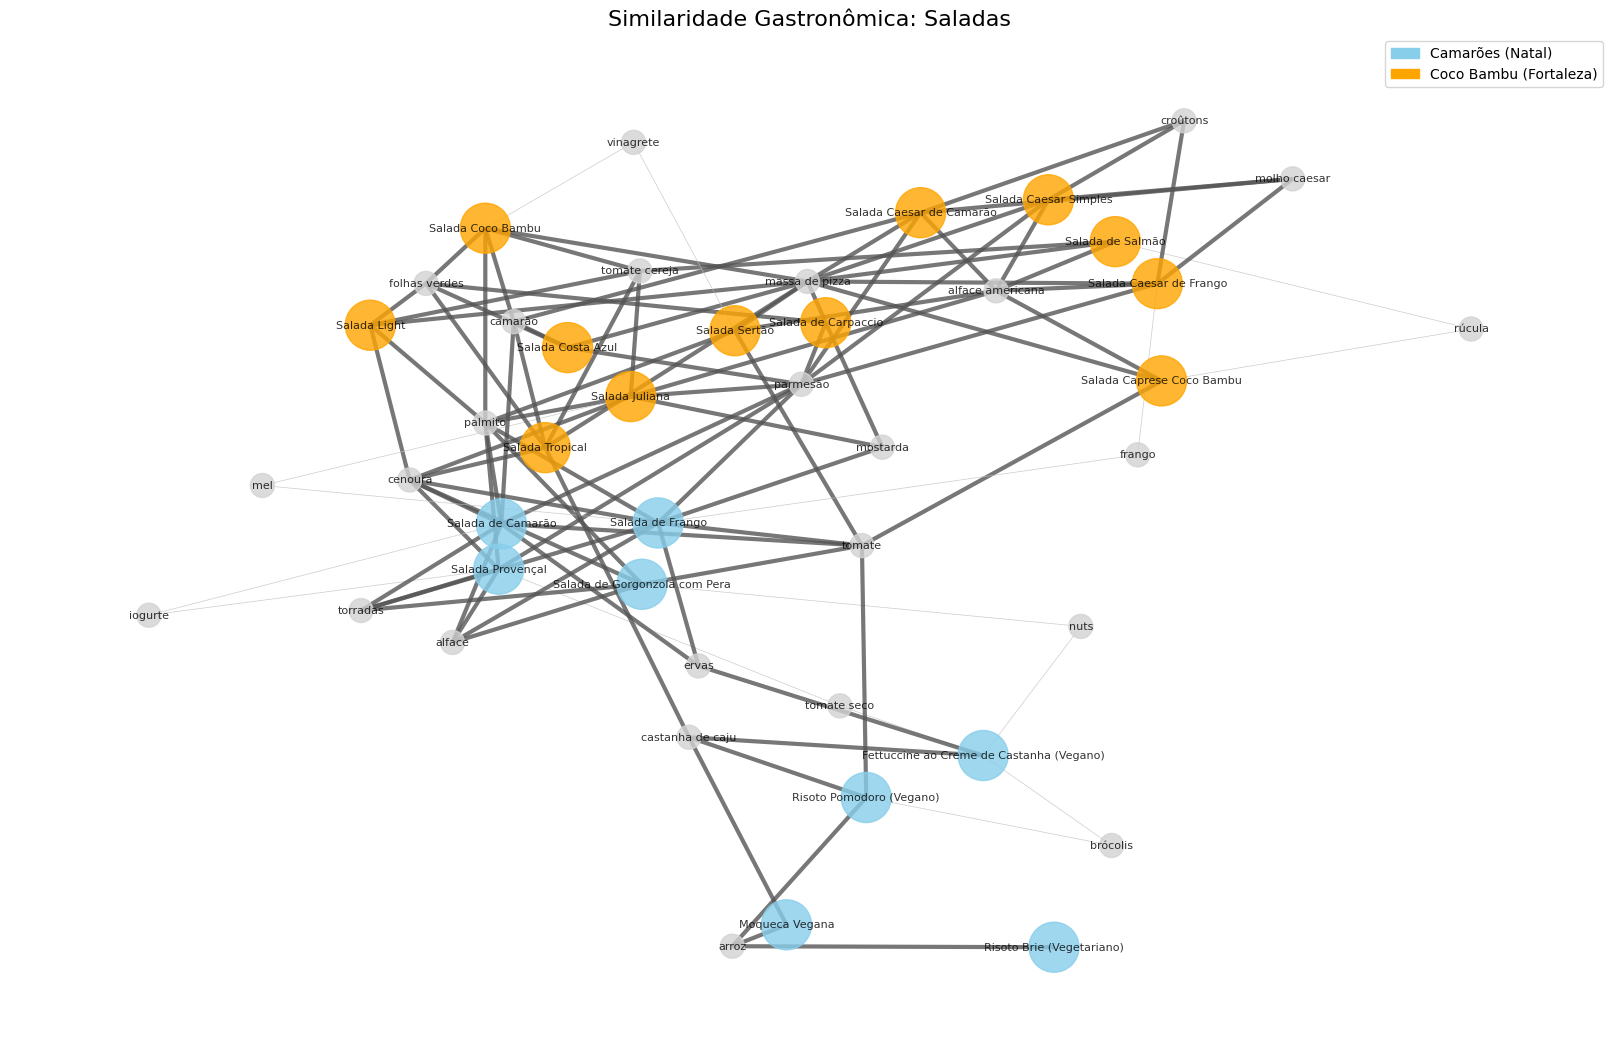


 Top Similares em Saladas:
 41.7% | (Camarões) Salada de Frango <-> (Coco Bambu) Salada Juliana
 27.3% | (Camarões) Salada Provençal <-> (Coco Bambu) Salada Juliana
 23.1% | (Camarões) Salada de Camarão <-> (Coco Bambu) Salada Juliana
 22.2% | (Camarões) Salada de Gorgonzola com Pera <-> (Coco Bambu) Salada Light
 22.2% | (Camarões) Salada de Gorgonzola com Pera <-> (Coco Bambu) Salada Sertão


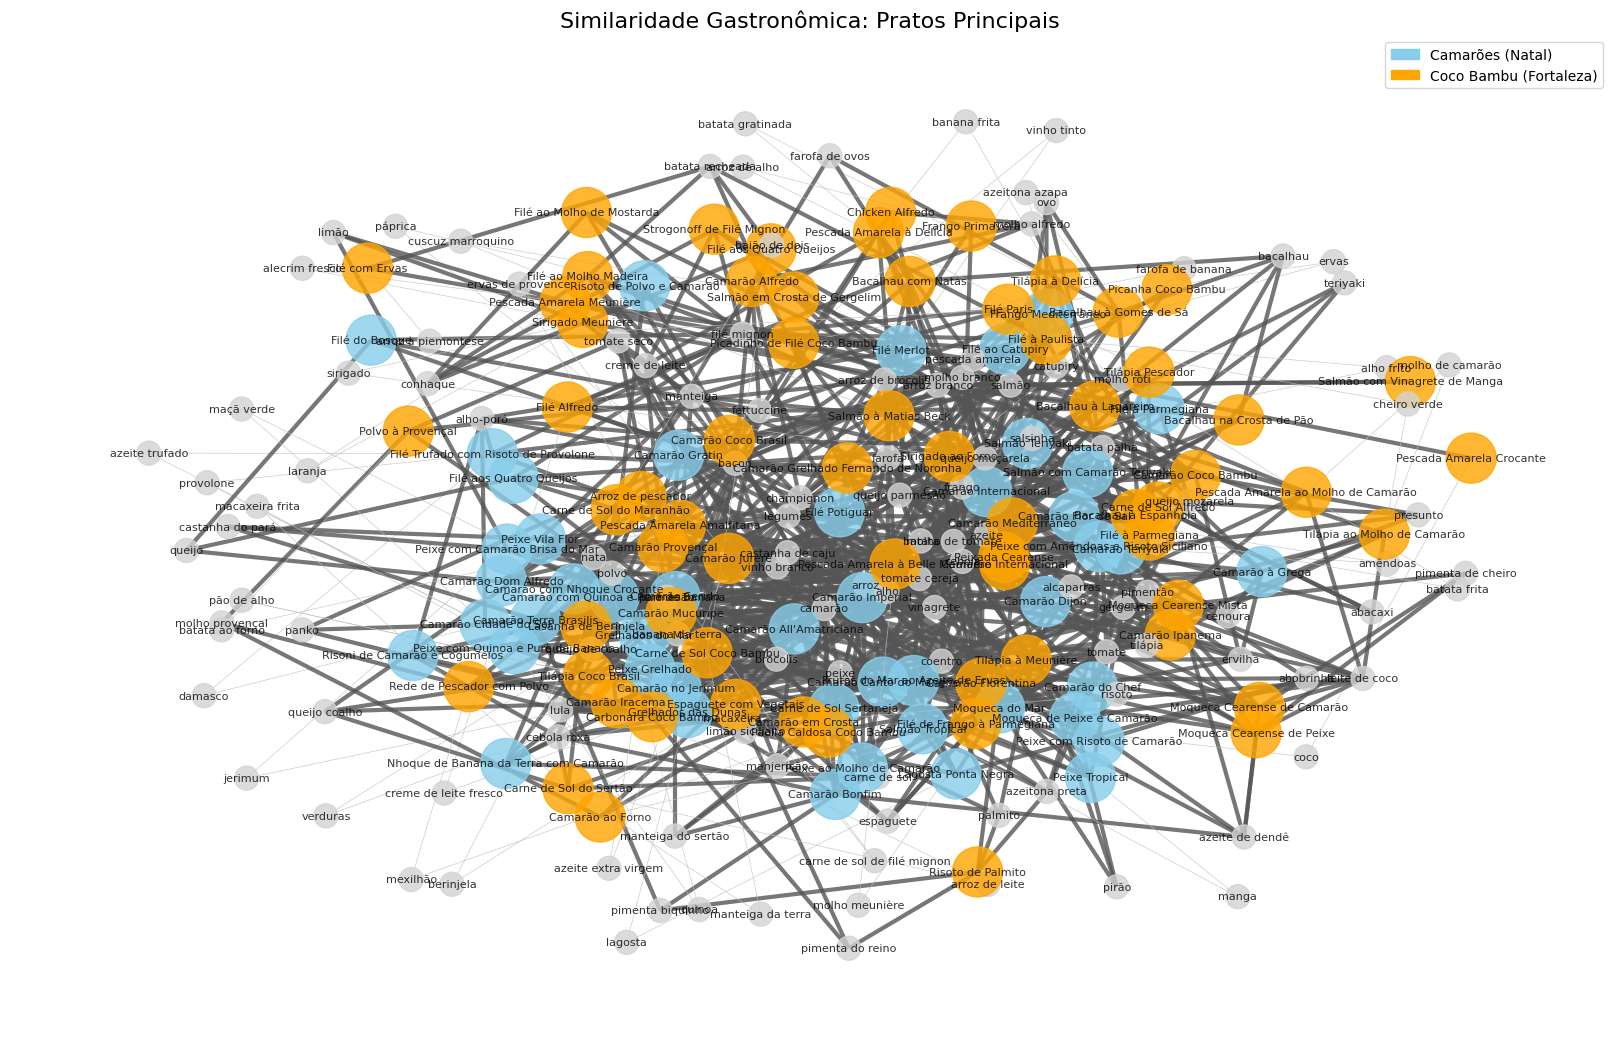


 Top Similares em Pratos Principais:
 77.8% | (Camarões) Camarão Internacional <-> (Coco Bambu) Camarão Internacional
 70.0% | (Camarões) Camarão Internacional <-> (Coco Bambu) Camarão Coco Bambu
 66.7% | (Camarões) Moqueca de Peixe e Camarão <-> (Coco Bambu) Moqueca Cearense Mista
 58.3% | (Camarões) Moqueca de Peixe e Camarão <-> (Coco Bambu) Moqueca Cearense de Camarão
 58.3% | (Camarões) Moqueca de Peixe e Camarão <-> (Coco Bambu) Moqueca Cearense de Peixe


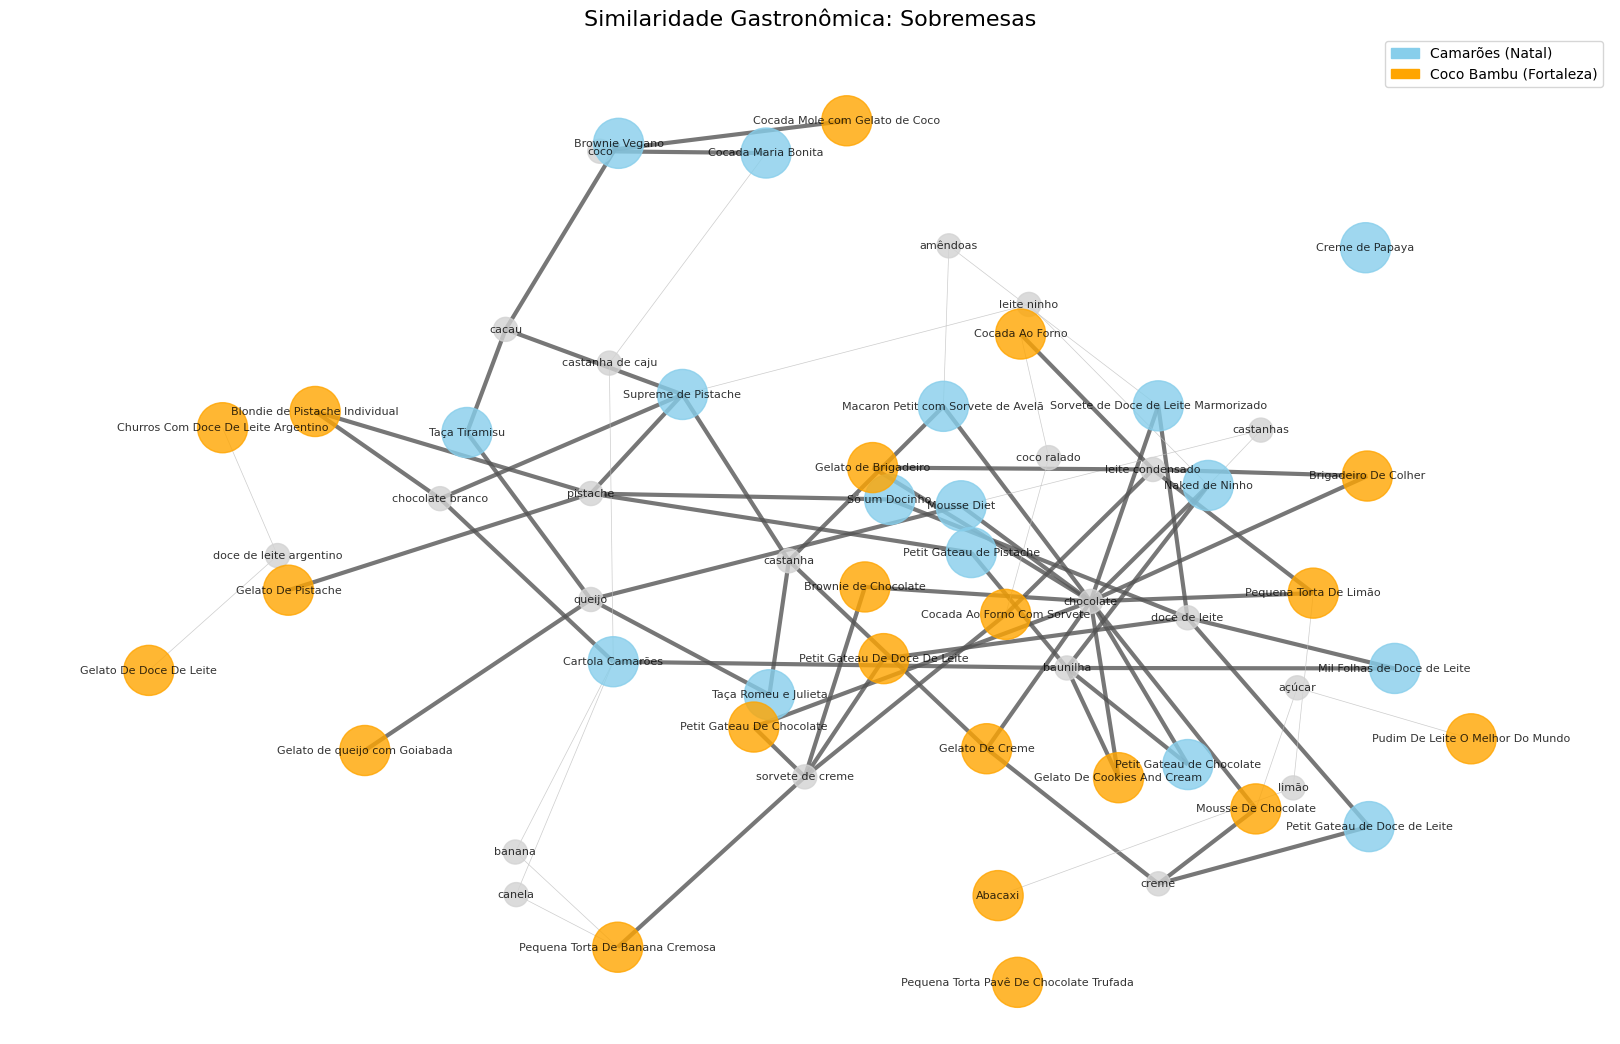


 Top Similares em Sobremesas:
 100.0% | (Camarões) Petit Gateau de Chocolate <-> (Coco Bambu) Gelato De Cookies And Cream
 50.0% | (Camarões) Petit Gateau de Pistache <-> (Coco Bambu) Gelato De Pistache
 50.0% | (Camarões) Taça Romeu e Julieta <-> (Coco Bambu) Gelato de queijo com Goiabada
 50.0% | (Camarões) Taça Tiramisu <-> (Coco Bambu) Gelato de queijo com Goiabada
 50.0% | (Camarões) Naked de Ninho <-> (Coco Bambu) Gelato De Cookies And Cream
✅ Matriz entradas salva!
✅ Matriz saladas salva!
✅ Matriz principais salva!
✅ Matriz sobremesas salva!


In [11]:
# Execução por categoria
E = plotar_analise_final('Entradas')
S = plotar_analise_final('Saladas')
P = plotar_analise_final('Pratos Principais')
SB = plotar_analise_final('Sobremesas')


# Função para salvar matriz de adjacência (ED2 Core)
def salvar_matriz(grafo, nome):
    nodelist = list(grafo.nodes())
    A = nx.adjacency_matrix(grafo, nodelist=nodelist).toarray()
    df = pd.DataFrame(A, index=nodelist, columns=nodelist)
    df.to_csv(f"../data/matriz_adj/matriz_{nome}.csv")
    print(f"✅ Matriz {nome} salva!")

# Salva todas as matrizes
for g, n in [(E, "entradas"), (S, "saladas"), (P, "principais"), (SB, "sobremesas")]:
    salvar_matriz(g, n)

6. Extração da Matriz de Adjacência

Conversão da estrutura topológica do grafo em uma representação algébrica. Esta matriz de adjacência é exportada para CSV, permitindo auditorias e usos em outros modelos matemáticos.

In [ ]:
import pandas as pd
import networkx as nx
import os

# 1. Mapeamento das variáveis para nomes de arquivos
subgrafos = {
    "Entradas": E,
    "Pratos_Principais": P,
    "Saladas": S,
    "Sobremesas": SB
}

# 2. Caminho da pasta de saída
output_dir = "../data/matriz_adj/"
os.makedirs(output_dir, exist_ok=True)

print("--- Gerando Matrizes de Adjacência por Categoria ---")

for nome, grafo in subgrafos.items():
    # Verifica se a variável existe e não está vazia
    if grafo is not None and len(grafo.nodes()) > 0:
        # Garante a ordem dos nós para a matriz
        nodelist = list(grafo.nodes())
        
        # Gera a matriz de adjacência (formato array)
        A = nx.adjacency_matrix(grafo, nodelist=nodelist).toarray()
        
        # Cria o DataFrame com rótulos
        df_adj = pd.DataFrame(A, index=nodelist, columns=nodelist)
        
        # Salva o arquivo CSV correspondente
        file_name = f"matriz_adj_{nome.lower()}.csv"
        file_path = os.path.join(output_dir, file_name)
        df_adj.to_csv(file_path)
        
        print(f" {nome}: Salva em {file_name} | Dimensões: {df_adj.shape}")
    else:
        print(f" {nome}: Grafo vazio ou variável não definida.")

print("\n📍 Todos os arquivos estão disponíveis em: data/matriz_adj/")

--- Gerando Matrizes de Adjacência por Categoria ---
✅ Entradas: Salva em matriz_adj_entradas.csv | Dimensões: (113, 113)
✅ Pratos_Principais: Salva em matriz_adj_pratos_principais.csv | Dimensões: (235, 235)
✅ Saladas: Salva em matriz_adj_saladas.csv | Dimensões: (45, 45)
✅ Sobremesas: Salva em matriz_adj_sobremesas.csv | Dimensões: (59, 59)

📍 Todos os arquivos estão disponíveis em: data/matriz_adj/
